<table class="tfo-notebook-buttons" align="left">
<td style="border: none;">
<a target="blank" href="https://colab.research.google.com/github/Hari31416/Portfolio/blob/main/Titanic/Models%20I.ipynb?hl=en"><img src="https://colab.research.google.com/img/colab_favicon_256px.png" width="28" height="28"/>Run on Google Colab</a></td>
<td style="border: none;">
<a target="blank" href="https://github.com/Hari31416/Portfolio/blob/main/Titanic/Models%20I.ipynb"><img src="https://cdn.icon-icons.com/icons2/2368/PNG/512/github_logo_icon_143772.png" width="28" height="28"/>View on Github</a></td>
<td style="border: none;">
</table>

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## loading the data

In [72]:
train = pd.read_csv('train_final.csv')
test = pd.read_csv('test_final.csv')

In [3]:
train.head()

,Survived,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,0,3,0,1,0,2,0,1,0,0,...,0,1,0,0,0,0,0,1,-0.565587,-0.502445
1,1,1,1,1,0,2,0,0,0,0,...,0,1,0,1,0,0,0,0,0.624229,0.786845
2,1,3,1,0,0,1,0,1,0,1,...,0,1,0,0,0,0,0,1,-0.268133,-0.488854
3,1,1,1,1,0,2,0,1,0,0,...,0,0,0,1,0,0,0,0,0.401138,0.420730
4,0,3,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0.401138,-0.486337


In [4]:
test.head()

,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,3,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0.337221,-0.497350
1,3,1,1,0,2,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1.302134,-0.512214
2,2,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,2.460031,-0.464037
3,3,0,0,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,1,-0.241727,-0.482412
4,3,1,1,1,3,0,1,0,0,0,...,0,0,0,0,0,0,0,1,-0.627692,-0.417429


In [73]:
columns = test.columns
columns

Index(['Pclass', 'Sex', 'SibSp', 'Parch', 'FamilySize', 'Embarked_Q',
       'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Other', 'Title_Rev', 'Ticket_first_letter_2',
       'Ticket_first_letter_3', 'Ticket_first_letter_4',
       'Ticket_first_letter_6', 'Ticket_first_letter_7',
       'Ticket_first_letter_X', 'Cabin_First_B', 'Cabin_First_C',
       'Cabin_First_D', 'Cabin_First_E', 'Cabin_First_F', 'Cabin_First_N',
       'Age', 'Fare'],
      dtype='object')

In [74]:
X = train.drop(['Survived'], axis=1).values
y = train['Survived'].values

### Creating the train and test data

In [16]:
len(X)

891

Since there are just 891 rows in the train data, we will use a test size of 0.25 to create the test data.

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [76]:
len(X_train),len(X_test)

(668, 223)

## Modeling

### Procedure

Since we have already standardized the data, we'll jump directly to the model creation. We'll start from the simplest, `LinearRegression` and keep on increasing the complexity until we get a good model. The process will be as follows:
1. Create a model using default parameters
2. Fit the model to the training data and get model performance
3. Create a `GridSearchCV` object to find the best parameters for the model
4. Fit the model to the training data and get model performance
5. Repeat steps 1-4 for different models

Since this is a classification problem, the models we'll use are:
1. `LogisticRegression`
2. `KNeighborsClassifier`
3. `SVC`
4. `DecisionTreeClassifier`
5. `RandomForestClassifier`
6. `GaussianNB`
7. `GradientBoostingClassifier`
8. `XGBClassifier`
9. `BaggingClassifier`
10. `AdaBoostClassifier`
11. `ExtraTreesClassifier`
...and more( if I can find them!).

With every model, I'll briefly describe the parameters that we'll be using. If we created all these models in a single notebook, it will be huge. So I'll create a number of notebooks.

To keeptrack of various models and their performance, I'll create a dictionary with model name as key and a list of performance metrics as value.

### Performance Metrics

In previous notebook, we saw that this classification is not perfectly balanced as only about 39% passengers survived. So `accuracy` is not that good a metric. However, we'll be using accuracy along with `precision`, `recall`, `f1_score` and  `roc_auc_score` to evaluate the model performance. These are the parameters, we'll be saving in the dictionary. We'll also plot the confusion matrix and ROC curve. So, the metrics we'll be saving in the dictionary are:
1. `accuracy`
2. `precision`
3. `recall`
4. `f1_score`
5. `roc_auc_score`

Let's create some helper functions.

### Helper Functions

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

model_performance = {}

def visualize_model(model, features = X_test):
    """
    This function plots the confusion metrics and classification report

    Parameters
    ----------
    model : sklearn model

    Returns
    -------
    None
    """
    #predicting on the data
    y_pred = lr_base.predict(features)
    
    #Printing the classification report
    print(classification_report(y_test, y_pred))
    
    #Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

def evaluate_model(model, model_name = None):
    """
    The function takes a model as input and creats a dictionary with the model's \\
        accuracy, precision, recall, f1 score, and roc_auc_score and add them to the \\
        `model_performance` dictionary and returns it. The `model_performance` dictionary \\
        is instantiated just before this function is created.

    Parameters
    ----------
    model : sklearn model

    Returns
    -------
    model_performance : dictionary
    """
    #Making predictions on the test set
    y_pred = model.predict(X_test)

    #Getting the metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    #Adding the metrics to the model_performance dictionary
    if model_name is None:
        model_name = type(model).__name__

    model_performance[model_name] = {
            'accuracy': accuracy, 'precision': precision, 
            'recall': recall, 'f1': f1, 'roc_auc': roc_auc}
    return model_performance


## Linear Regression

In [78]:
from sklearn.linear_model import LogisticRegression, Lasso, Ridge

lr_base = LogisticRegression()
lr_base.fit(X_train, y_train)

LogisticRegression()

In [79]:
evaluate_model(lr_base)

{'LogisticRegression': {'accuracy': 0.8026905829596412,
  'precision': 0.7472527472527473,
  'recall': 0.7640449438202247,
  'f1': 0.7555555555555554,
  'roc_auc': 0.7962015763877244}}

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       134
           1       0.75      0.76      0.76        89

    accuracy                           0.80       223
   macro avg       0.79      0.80      0.80       223
weighted avg       0.80      0.80      0.80       223



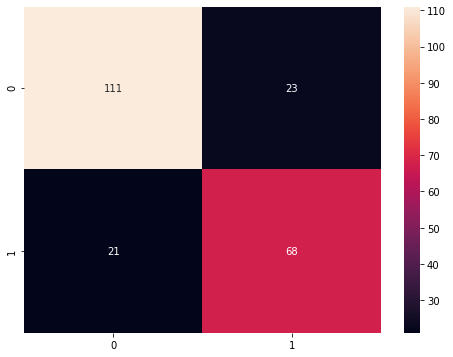

In [80]:
visualize_model(lr_base)